In [4]:
import matplotlib.pyplot as plt

import platform

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

In [1]:
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 生成数据
X, y = make_classification(n_samples=300, n_features=2, 
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=42)

# 标准化很重要！
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# 创建SVM模型
# 线性核
svm_linear = svm.SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

# RBF核（最常用）
svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)

# 评估
print(f"Linear SVM accuracy: {svm_linear.score(X_test, y_test):.3f}")
print(f"RBF SVM accuracy: {svm_rbf.score(X_test, y_test):.3f}")

# 获取支持向量
print(f"Number of support vectors: {len(svm_rbf.support_)}")

Linear SVM accuracy: 0.956
RBF SVM accuracy: 0.956
Number of support vectors: 38


In [2]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid = GridSearchCV(svm.SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

Best parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validation score: 0.976


1. 展示不同SVM在不同数据集上的表现...


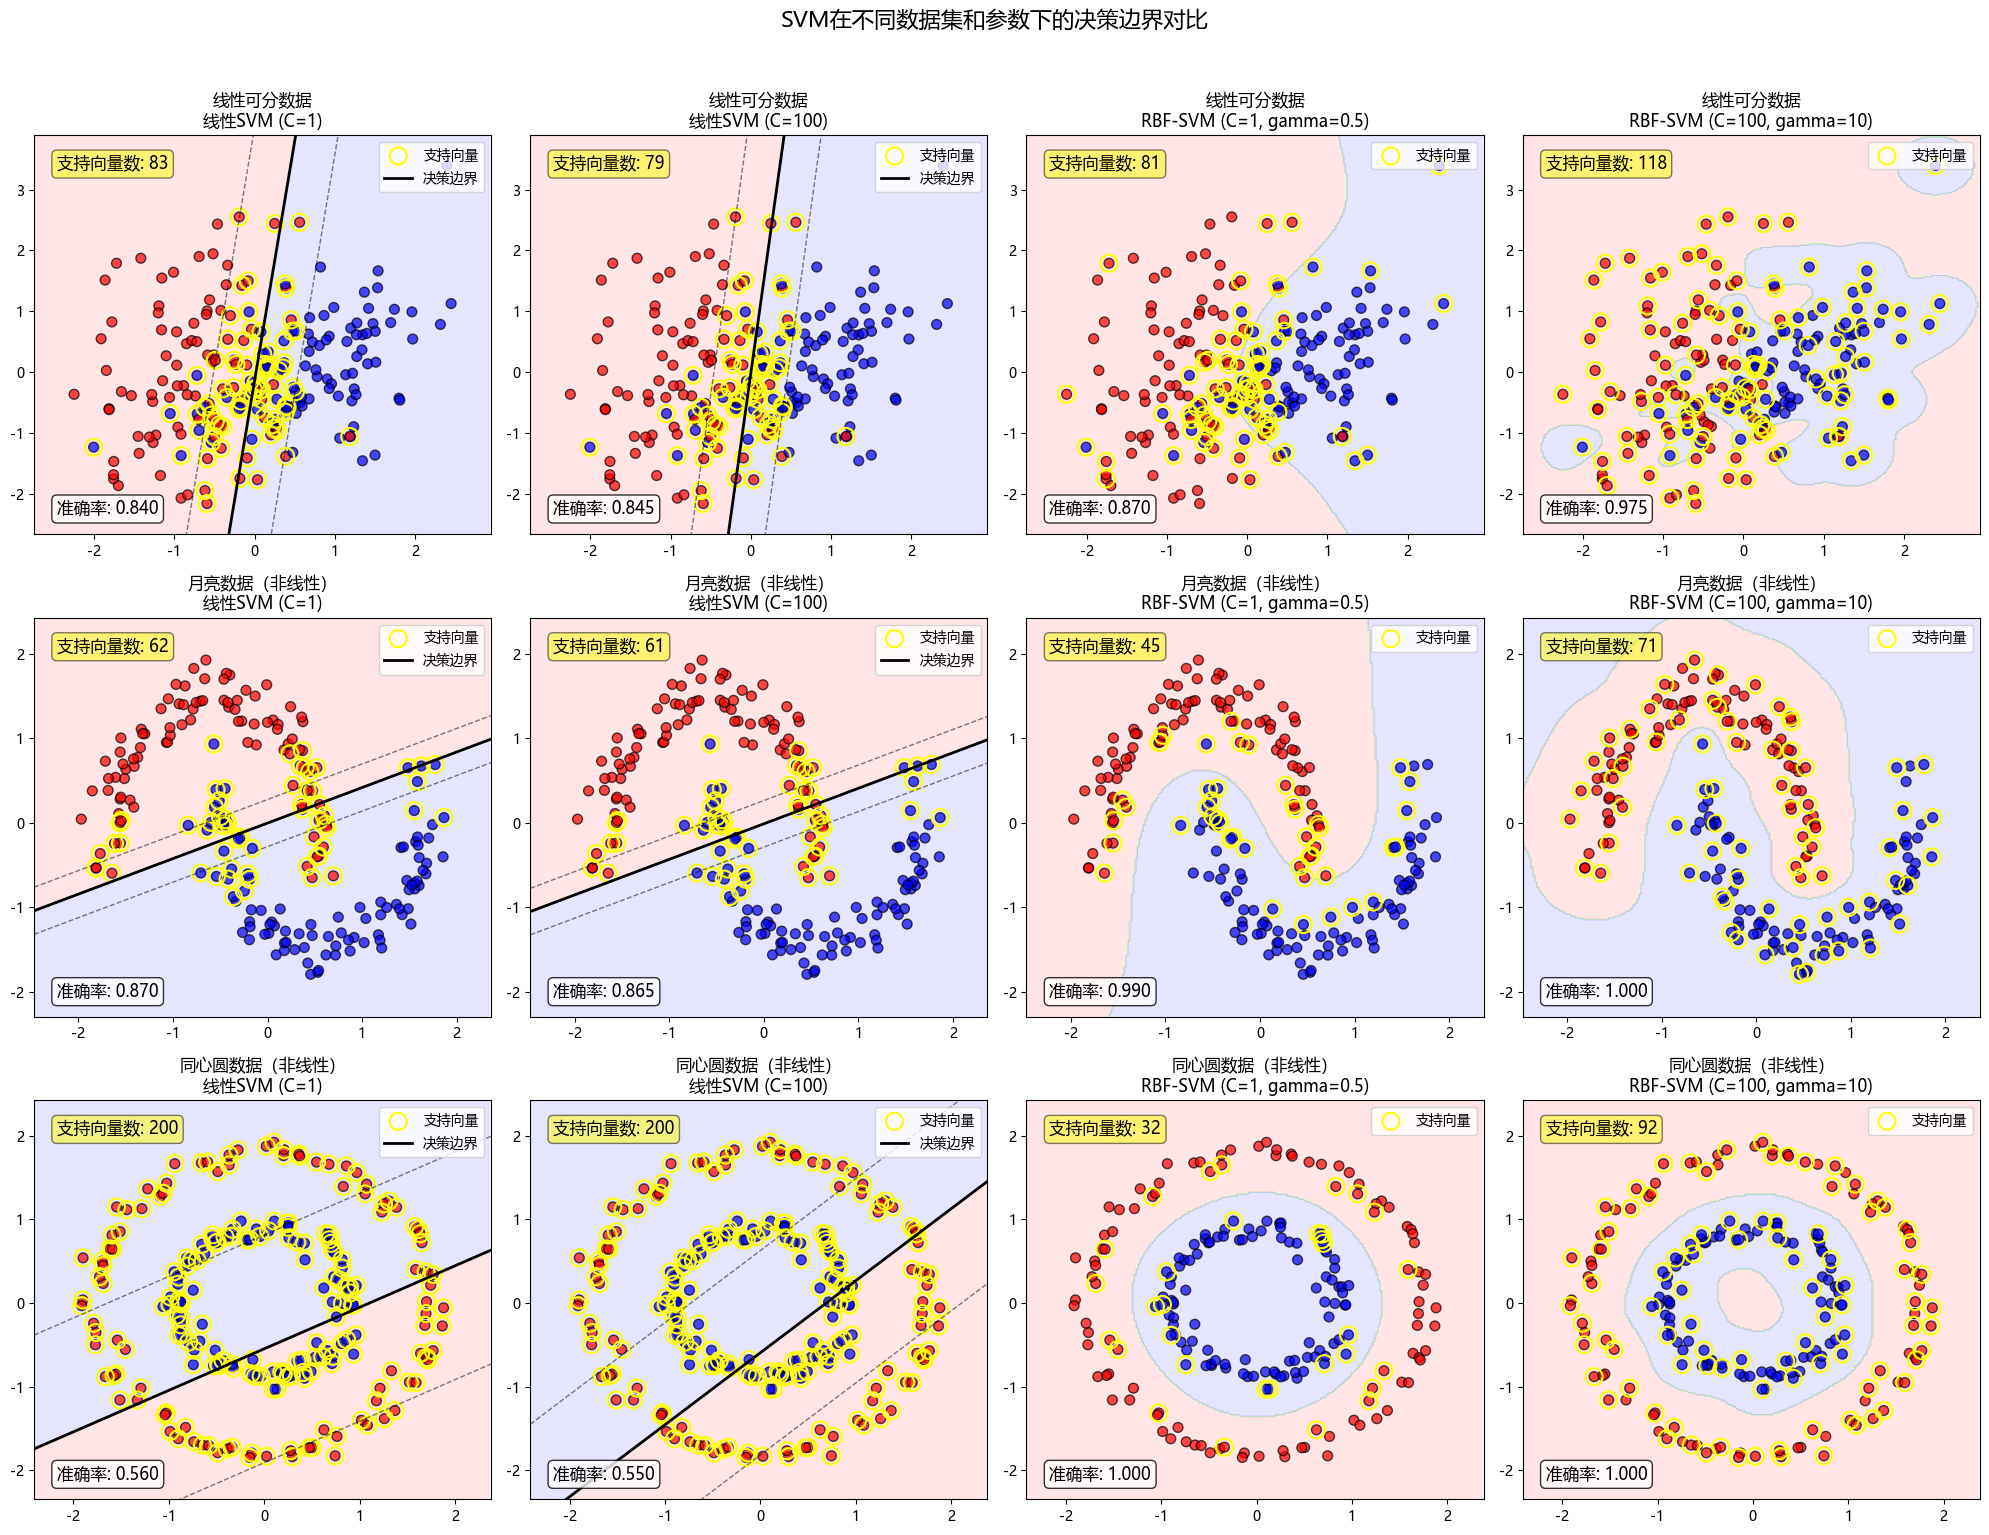


2. 展示参数C和gamma的影响...


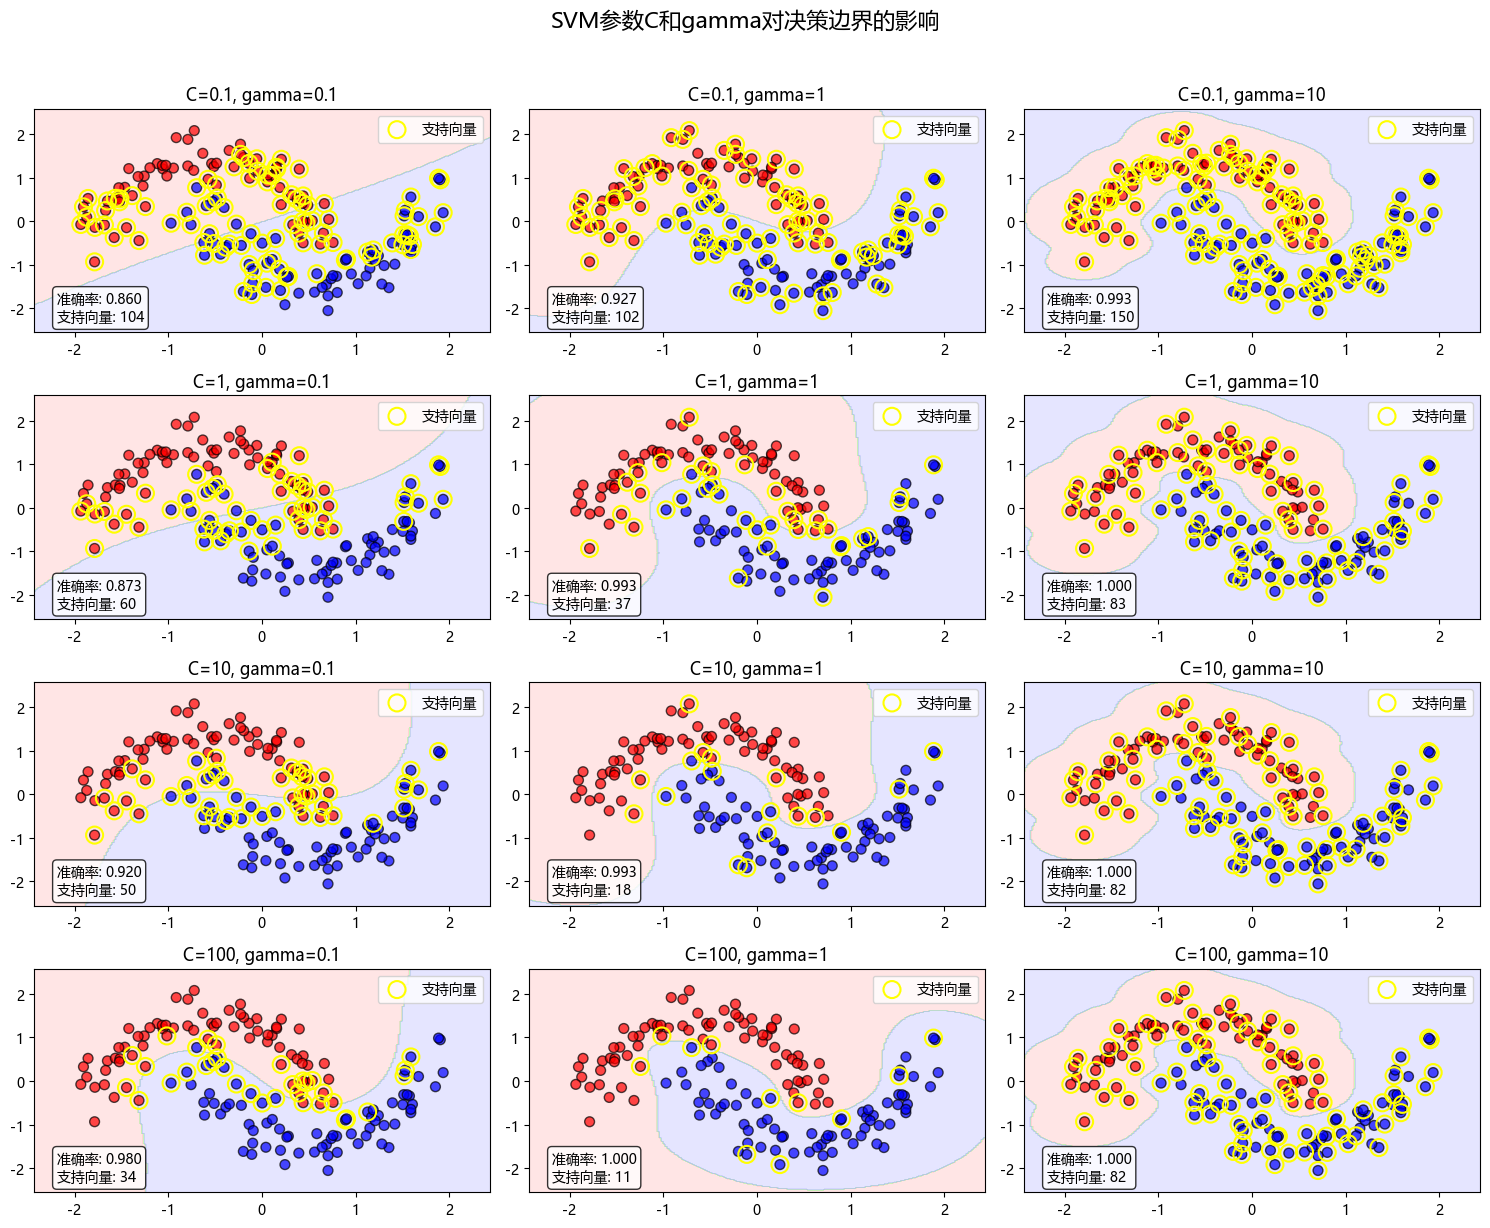


3. 展示概率估计...


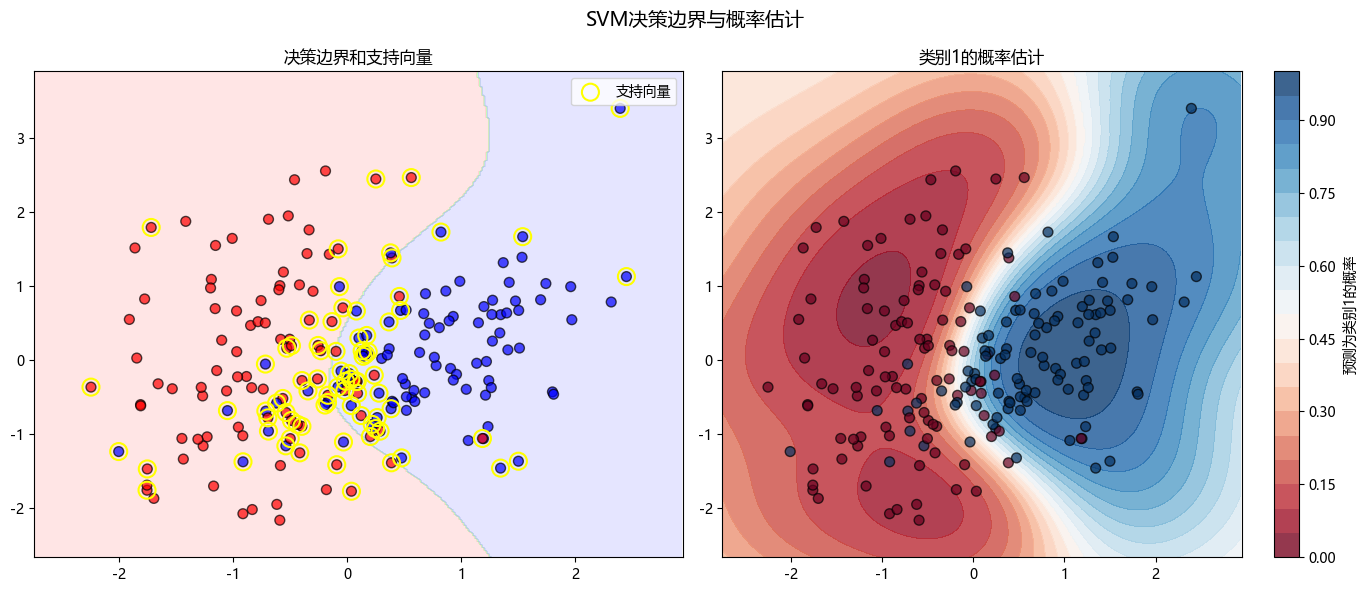


4. 展示3D决策面...


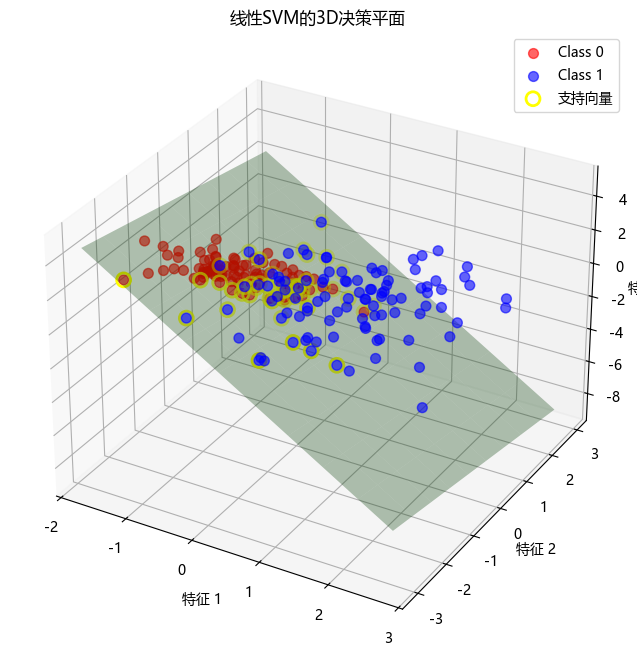

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# 设置中文字体（解决中文显示问题）
# plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

def plot_decision_boundary(clf, X, y, title, ax=None):
    """
    绘制SVM决策边界和支持向量
    """
    if ax is None:
        ax = plt.gca()
    
    # 创建网格
    h = 0.02  # 网格步长
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 预测网格上每个点的类别
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    
    # 绘制训练点
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, 
                        edgecolor='black', s=50, alpha=0.7)
    
    # 高亮显示支持向量
    if hasattr(clf, 'support_vectors_'):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                  s=150, linewidth=1.5, facecolors='none', 
                  edgecolors='yellow', label='支持向量')
    
    # 如果是线性SVM，绘制决策超平面
    if clf.kernel == 'linear' and hasattr(clf, 'coef_'):
        # 绘制决策边界直线
        w = clf.coef_[0]
        a = -w[0] / w[1]
        xx_plane = np.linspace(x_min, x_max)
        yy_plane = a * xx_plane - (clf.intercept_[0]) / w[1]
        ax.plot(xx_plane, yy_plane, 'k-', linewidth=2, label='决策边界')
        
        # 绘制间隔边界
        margin = 1 / np.sqrt(np.sum(clf.coef_ ** 2))
        yy_down = yy_plane - a * margin
        yy_up = yy_plane + a * margin
        ax.plot(xx_plane, yy_down, 'k--', linewidth=1, alpha=0.5)
        ax.plot(xx_plane, yy_up, 'k--', linewidth=1, alpha=0.5)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title)
    ax.legend(loc='upper right')
    
    return scatter

def visualize_svm_comparison():
    """
    综合可视化：比较不同SVM在不同数据集上的表现
    """
    # 创建3个不同特性的数据集
    datasets = []
    
    # 数据集1：线性可分
    X1, y1 = make_classification(n_samples=200, n_features=2, 
                                 n_redundant=0, n_clusters_per_class=1,
                                 n_classes=2, random_state=42)
    datasets.append(("线性可分数据", X1, y1))
    
    # 数据集2：月亮形状（非线性）
    X2, y2 = make_moons(n_samples=200, noise=0.1, random_state=42)
    datasets.append(("月亮数据（非线性）", X2, y2))
    
    # 数据集3：同心圆（非线性）
    X3, y3 = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
    datasets.append(("同心圆数据（非线性）", X3, y3))
    
    # 不同的SVM配置
    svm_configs = [
        ("线性SVM (C=1)", svm.SVC(kernel='linear', C=1.0)),
        ("线性SVM (C=100)", svm.SVC(kernel='linear', C=100.0)),
        ("RBF-SVM (C=1, gamma=0.5)", svm.SVC(kernel='rbf', C=1.0, gamma=0.5)),
        ("RBF-SVM (C=100, gamma=10)", svm.SVC(kernel='rbf', C=100.0, gamma=10.0)),
    ]
    
    # 创建大图
    fig, axes = plt.subplots(len(datasets), len(svm_configs), 
                             figsize=(20, 15))
    
    for i, (data_name, X, y) in enumerate(datasets):
        # 标准化数据
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        for j, (svm_name, clf) in enumerate(svm_configs):
            ax = axes[i, j]
            
            # 训练SVM
            clf.fit(X_scaled, y)
            
            # 绘制决策边界
            plot_decision_boundary(clf, X_scaled, y, f"{data_name}\n{svm_name}", ax)
            
            # 添加准确率
            accuracy = clf.score(X_scaled, y)
            ax.text(0.05, 0.05, f'准确率: {accuracy:.3f}', 
                   transform=ax.transAxes, fontsize=12,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
            # 显示支持向量数量
            n_sv = len(clf.support_)
            ax.text(0.05, 0.95, f'支持向量数: {n_sv}', 
                   transform=ax.transAxes, fontsize=12,
                   verticalalignment='top',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))
    
    plt.suptitle('SVM在不同数据集和参数下的决策边界对比', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def visualize_training_process():
    """
    可视化SVM训练过程中的参数影响
    """
    # 生成月亮数据集
    X, y = make_moons(n_samples=150, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 测试不同的C和gamma组合
    C_values = [0.1, 1, 10, 100]
    gamma_values = [0.1, 1, 10]
    
    fig, axes = plt.subplots(len(C_values), len(gamma_values), 
                             figsize=(15, 12))
    
    for i, C in enumerate(C_values):
        for j, gamma in enumerate(gamma_values):
            ax = axes[i, j]
            
            # 训练RBF-SVM
            clf = svm.SVC(kernel='rbf', C=C, gamma=gamma)
            clf.fit(X_scaled, y)
            
            # 绘制决策边界
            plot_decision_boundary(clf, X_scaled, y, 
                                  f'C={C}, gamma={gamma}', ax)
            
            # 显示准确率和支持向量数
            acc = clf.score(X_scaled, y)
            n_sv = len(clf.support_)
            ax.text(0.05, 0.05, f'准确率: {acc:.3f}\n支持向量: {n_sv}', 
                   transform=ax.transAxes, fontsize=10,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.suptitle('SVM参数C和gamma对决策边界的影响', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def visualize_probability_estimation():
    """
    可视化SVM的概率估计（需要probability=True）
    """
    # 生成数据
    X, y = make_classification(n_samples=200, n_features=2, 
                               n_redundant=0, n_clusters_per_class=1,
                               n_classes=2, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 训练带概率输出的SVM
    clf = svm.SVC(kernel='rbf', C=1.0, gamma=0.5, probability=True)
    clf.fit(X_scaled, y)
    
    # 创建网格
    h = 0.02
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 预测概率
    Z_proba = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z_proba = Z_proba.reshape(xx.shape)
    
    # 创建子图
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 左图：决策边界
    ax1 = axes[0]
    plot_decision_boundary(clf, X_scaled, y, "决策边界和支持向量", ax1)
    
    # 右图：概率热力图
    ax2 = axes[1]
    contour = ax2.contourf(xx, yy, Z_proba, alpha=0.8, cmap='RdBu', levels=20)
    ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='RdBu', 
               edgecolor='black', s=50, alpha=0.7)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_title('类别1的概率估计')
    plt.colorbar(contour, ax=ax2, label='预测为类别1的概率')
    
    plt.suptitle('SVM决策边界与概率估计', fontsize=14)
    plt.tight_layout()
    plt.show()

def visualize_3d_svm():
    """
    3D可视化SVM决策面（如果是线性SVM）
    """
    from sklearn.datasets import make_classification
    
    # 生成3D数据
    X, y = make_classification(n_samples=200, n_features=3, 
                               n_redundant=0, n_informative=3,
                               n_clusters_per_class=1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 训练线性SVM
    clf = svm.SVC(kernel='linear', C=1.0)
    clf.fit(X_scaled, y)
    
    # 创建3D图
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 绘制数据点
    colors = ['red', 'blue']
    for i, color in enumerate(colors):
        mask = y == i
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], X_scaled[mask, 2],
                  c=color, s=50, alpha=0.6, label=f'Class {i}')
    
    # 绘制决策平面（对于线性SVM）
    if clf.kernel == 'linear':
        w = clf.coef_[0]
        b = clf.intercept_[0]
        
        # 创建网格
        xx, yy = np.meshgrid(np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 10),
                            np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 10))
        zz = (-w[0] * xx - w[1] * yy - b) / w[2]
        
        # 绘制平面
        ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')
    
    # 高亮支持向量
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], sv[:, 2], s=100, 
              facecolors='none', edgecolors='yellow', 
              linewidth=2, label='支持向量')
    
    ax.set_xlabel('特征 1')
    ax.set_ylabel('特征 2')
    ax.set_zlabel('特征 3')
    ax.set_title('线性SVM的3D决策平面')
    ax.legend()
    
    plt.show()

# 主函数：运行所有可视化
if __name__ == "__main__":
    print("1. 展示不同SVM在不同数据集上的表现...")
    visualize_svm_comparison()
    
    print("\n2. 展示参数C和gamma的影响...")
    visualize_training_process()
    
    print("\n3. 展示概率估计...")
    visualize_probability_estimation()
    
    print("\n4. 展示3D决策面...")
    visualize_3d_svm()

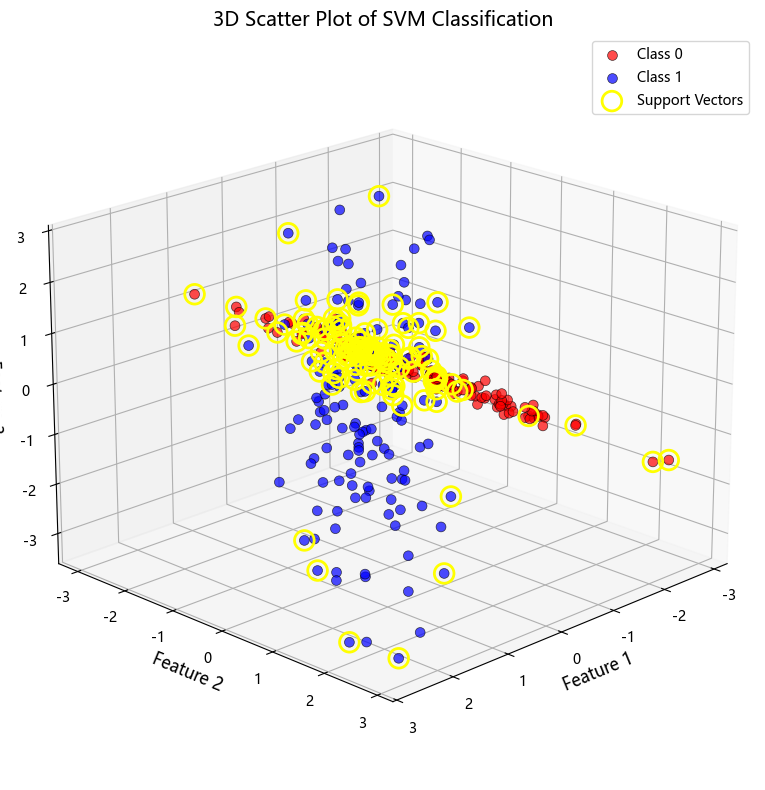

Accuracy: 0.880
Number of support vectors: 128


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# 生成3D数据
X, y = make_classification(n_samples=300, n_features=3, 
                           n_redundant=0, n_informative=3,
                           n_clusters_per_class=1, 
                           n_classes=2, random_state=42)

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练SVM
clf = svm.SVC(kernel='rbf', C=1.0, gamma=0.5)
clf.fit(X_scaled, y)

# 创建3D散点图
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 根据类别设置不同颜色
colors = ['red', 'blue']
for i, color in enumerate(colors):
    mask = y == i
    ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], X_scaled[mask, 2],
              c=color, s=50, alpha=0.7, label=f'Class {i}', 
              edgecolors='black', linewidth=0.5)

# 高亮支持向量
support_vectors = clf.support_vectors_
ax.scatter(support_vectors[:, 0], support_vectors[:, 1], support_vectors[:, 2],
          s=200, facecolors='none', edgecolors='yellow', 
          linewidth=2, label='Support Vectors', alpha=1)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_zlabel('Feature 3', fontsize=12)
ax.set_title('3D Scatter Plot of SVM Classification', fontsize=14)
ax.legend(fontsize=10)

# 设置视角
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

print(f"Accuracy: {clf.score(X_scaled, y):.3f}")
print(f"Number of support vectors: {len(support_vectors)}")

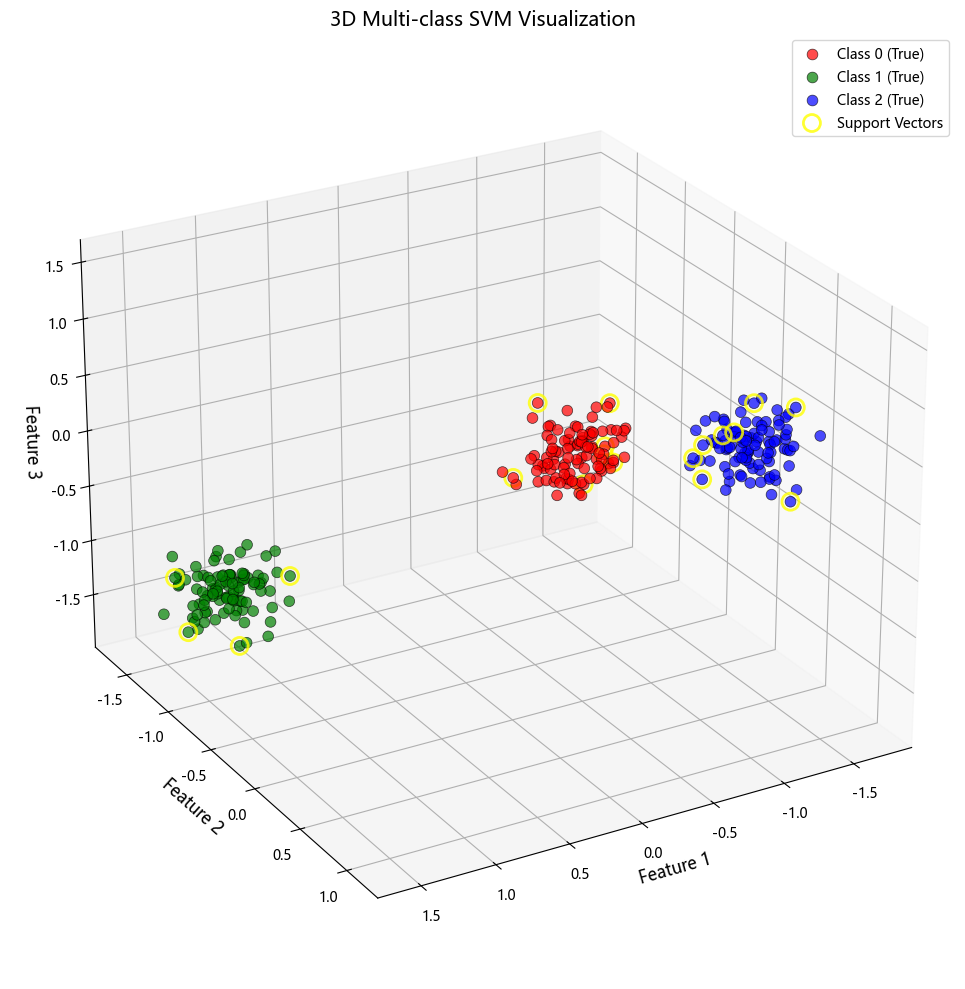

Accuracy: 1.000
Number of support vectors: 19


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import svm
from sklearn.datasets import make_blobs

# 生成3类数据
X, y = make_blobs(n_samples=300, n_features=3, centers=3,
                  cluster_std=0.8, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练多类别SVM（一对一策略）
clf = svm.SVC(kernel='rbf', C=1.0, gamma=0.5, decision_function_shape='ovo')
clf.fit(X_scaled, y)

# 预测
y_pred = clf.predict(X_scaled)

# 创建3D图
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 定义颜色和标签
colors = ['red', 'green', 'blue']
labels = ['Class 0', 'Class 1', 'Class 2']

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = y == i
    ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], X_scaled[mask, 2],
              c=color, s=60, alpha=0.7, label=f'{label} (True)',
              edgecolors='black', linewidth=0.5)

# 用不同标记显示预测错误的点
errors = y != y_pred
if np.any(errors):
    ax.scatter(X_scaled[errors, 0], X_scaled[errors, 1], X_scaled[errors, 2],
              s=200, facecolors='none', edgecolors='purple', 
              linewidth=2, label='Misclassified', alpha=0.8)

# 高亮支持向量
support_vectors = clf.support_vectors_
ax.scatter(support_vectors[:, 0], support_vectors[:, 1], support_vectors[:, 2],
          s=150, facecolors='none', edgecolors='yellow', 
          linewidth=2, label='Support Vectors', alpha=0.8)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_zlabel('Feature 3', fontsize=12)
ax.set_title('3D Multi-class SVM Visualization', fontsize=14)
ax.legend(fontsize=10, loc='upper right')

# 设置视角
ax.view_init(elev=25, azim=60)

plt.tight_layout()
plt.show()

print(f"Accuracy: {clf.score(X_scaled, y):.3f}")
print(f"Number of support vectors: {len(support_vectors)}")

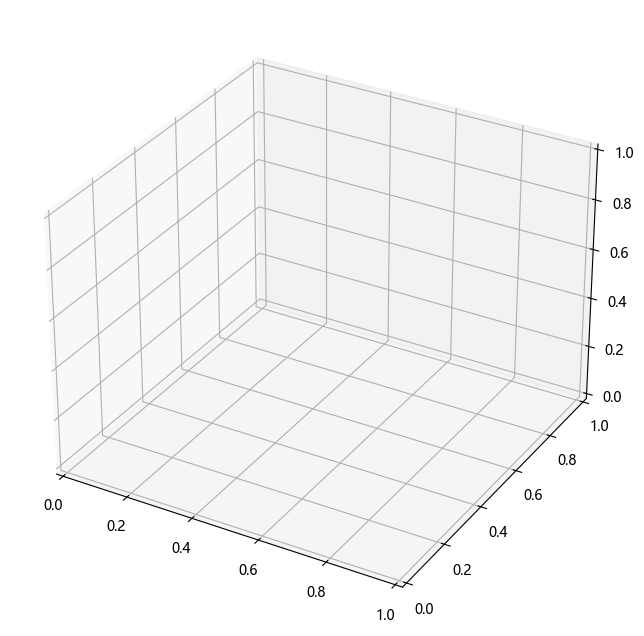

i:\git\docs-public\.venv\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from matplotlib.animation import FuncAnimation

# 生成数据
X, y = make_classification(n_samples=400, n_features=3, 
                           n_redundant=0, n_informative=3,
                           n_clusters_per_class=1,
                           n_classes=2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练SVM
clf = svm.SVC(kernel='rbf', C=1.0, gamma=0.5)
clf.fit(X_scaled, y)

# 创建动画
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

def update(angle):
    ax.clear()
    
    # 绘制数据点
    colors = ['red', 'blue']
    for i, color in enumerate(colors):
        mask = y == i
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], X_scaled[mask, 2],
                  c=color, s=50, alpha=0.7, label=f'Class {i}',
                  edgecolors='black', linewidth=0.5)
    
    # 绘制支持向量
    support_vectors = clf.support_vectors_
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], support_vectors[:, 2],
              s=200, facecolors='none', edgecolors='yellow', 
              linewidth=2, label='Support Vectors')
    
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title(f'SVM Classification (Angle: {angle}°)')
    ax.legend()
    ax.view_init(elev=20, azim=angle)

# 创建动画
anim = FuncAnimation(fig, update, frames=np.arange(0, 360, 5), 
                    interval=100, repeat=True)

# 保存为gif（需要安装pillow）
# anim.save('svm_3d_rotation.gif', writer='pillow', fps=20)